In [71]:
# Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# load training file and display first 5 rows
df = pd.read_csv('Titanic Data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1]:
# Dataset summary
df.info() 

In [49]:
# Drop useless columns
df = df.drop(['Name','Cabin','Ticket'], axis=1)

In [50]:
# Fill null age values with their respective class's average age
df['Age'] = df.groupby('Pclass')['Age'].transform( lambda x: x.fillna(x.median()))

In [51]:
# Fill null embarked values with most common occuring value
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

In [52]:
# Encode sex and embark (one hot encode)
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first = True)

In [53]:
# Display first 5 rows
df.head() 

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True


In [54]:
# Dataset summary
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked_Q   891 non-null    bool   
 9   Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(2), int64(6)
memory usage: 57.6 KB


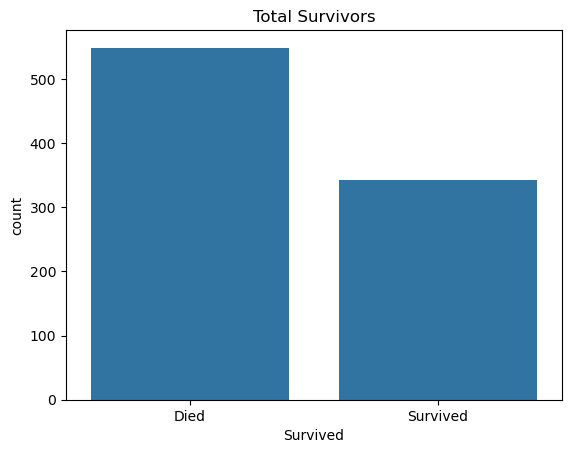

In [55]:
# Total survivor count
sns.countplot(x='Survived', data=df)
plt.xticks([0, 1], ['Died', 'Survived'])
plt.title('Total Survivors')
plt.show()

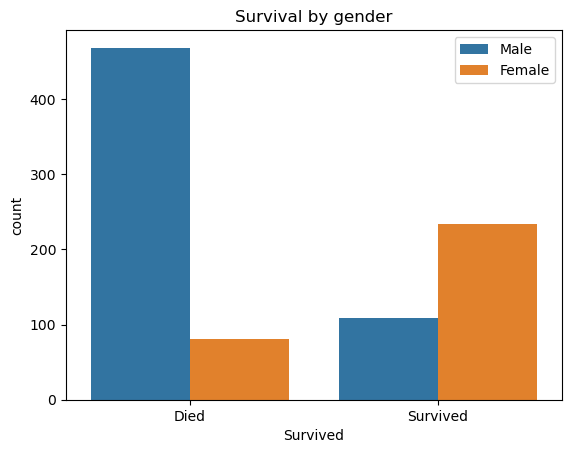

In [56]:
# Survivors grouped by genders
sns.countplot(x='Survived', hue = 'Sex', data=df)
plt.xticks([0, 1], ['Died', 'Survived'])
plt.legend(labels=['Male', 'Female'])
plt.title('Survival by gender')
plt.show()

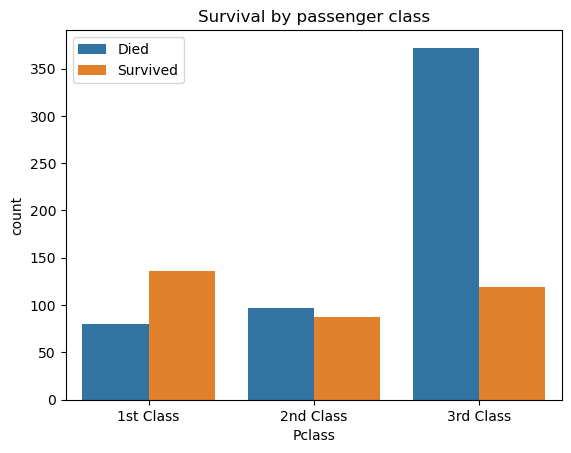

In [57]:
# Survivors grouped by passenger class
sns.countplot(x='Pclass', hue = 'Survived', data=df)
plt.title('Survival by passenger class')
plt.xticks([0,1,2], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(labels=['Died','Survived'])
plt.show()

In [78]:
# Splitting training and testing data for model
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

x=df.drop(['Survived', 'PassengerId'],axis=1)
y=df['Survived']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state = 42)

In [80]:
# Creating and training the model
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
# Making predictions, validating against actual result and converting in %
predictions = model.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print(f"Validation Accuracy: {accuracy:.2%}")

Validation Accuracy: 83.24%


In [ ]:
# Visualizing how many mistakes and correct predictions were made by the model: TN FP, FN TP
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Kaggle Submission

In [83]:
# Reading testing file
test = pd.read_csv('Titanic Data/test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [84]:
# Dropping unnnecessary columns, filling null values of age with passenger class avg age, fare with middle value, embarked with 
# most common occuring value while splitting and encoding it to 0 and 1s and dropping first column (idenfiable), sex encoded to nums

test = test.drop(['Cabin', 'Name', 'Ticket'], axis=1)
                
test ['Age'] = test.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

test['Fare'] = test['Fare'].fillna(test['Fare'].median())
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])
test['Sex'] = test['Sex'].map({'male':0, 'female':1})

test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Embarked_Q   418 non-null    bool   
 8   Embarked_S   418 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 23.8 KB


In [85]:
# Generating survival predictions on test data and saving as Kaggle submission file
test_predictions = model.predict(test.drop('PassengerId', axis=1))

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('Titanic Data/submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
